# （1）加载数据集，查看有哪些字段

In [2]:
import warnings
warnings.filterwarnings("ignore")
from sklearn.datasets import fetch_california_housing
data = fetch_california_housing()
dir(data)

['DESCR', 'data', 'feature_names', 'frame', 'target', 'target_names']

# （2）显示数据集的描述信息

In [2]:
print(data.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

    :Number of Instances: 20640

    :Number of Attributes: 8 numeric, predictive attributes and the target

    :Attribute Information:
        - MedInc        median income in block group
        - HouseAge      median house age in block group
        - AveRooms      average number of rooms per household
        - AveBedrms     average number of bedrooms per household
        - Population    block group population
        - AveOccup      average number of household members
        - Latitude      block group latitude
        - Longitude     block group longitude

    :Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived

# （3）查看样本的特征和标签

In [4]:
x=data.data
y=data.target
import numpy as np
np.set_printoptions(suppress=True, precision=2) 
print(x[:10], y[:10])

[[   8.33   41.      6.98    1.02  322.      2.56   37.88 -122.23]
 [   8.3    21.      6.24    0.97 2401.      2.11   37.86 -122.22]
 [   7.26   52.      8.29    1.07  496.      2.8    37.85 -122.24]
 [   5.64   52.      5.82    1.07  558.      2.55   37.85 -122.25]
 [   3.85   52.      6.28    1.08  565.      2.18   37.85 -122.25]
 [   4.04   52.      4.76    1.1   413.      2.14   37.85 -122.25]
 [   3.66   52.      4.93    0.95 1094.      2.13   37.84 -122.25]
 [   3.12   52.      4.8     1.06 1157.      1.79   37.84 -122.25]
 [   2.08   42.      4.29    1.12 1206.      2.03   37.84 -122.26]
 [   3.69   52.      4.97    0.99 1551.      2.17   37.84 -122.25]] [4.53 3.58 3.52 3.41 3.42 2.7  2.99 2.41 2.27 2.61]


# （4）将样本分为训练集和测试集

In [5]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test= train_test_split(x, y, test_size=0.3)

# （5）采用线性回归进行训练

In [6]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

# （6）用训练好的模型model进行预测

In [7]:
y_pred = model.predict(x_test)

# （7）查看真实标签与预测结果

In [8]:
 y_test[:10] , y_pred[:10], len(y_test)  , len(x)

(array([2.58, 1.59, 0.71, 1.29, 2.97, 1.94, 1.68, 0.91, 0.57, 4.34]),
 array([3.35, 2.04, 1.09, 1.28, 1.79, 1.52, 1.76, 1.25, 0.97, 2.71]),
 6192,
 20640)

# （8）查看模型的性能指标：mse，rmse，mae，r2

In [9]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
mse = mean_squared_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False) # sklearn 0.22+
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(mse, rmse, mae, r2)

0.5368854314317031 0.7327246627701999 0.5335919131013738 0.6036720099192039


# （9）将样本标签改为高低房价，为逻辑回归(分类)练习拆分训练集和测试集

In [10]:
import numpy
y_binary = (y > numpy.median(y)).astype(int) # 1 代表高房价, 0 代表低房价
x_train, x_test, y_train, y_test= train_test_split(x, y_binary, test_size=0.3)
y_test[:10] 

array([0, 0, 1, 0, 1, 1, 1, 1, 0, 1])

# （10）建立逻辑回归模型，并基于训练集进行训练

In [11]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

LogisticRegression(max_iter=1000)

# （11）使用训练好的模型进行分类

In [12]:
y_pred = model.predict(x_test)

# （12）评价分类结果

In [13]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
accuracy = accuracy_score(y_test, y_pred)
print("\n--- 模型评估结果 ---")
print(f"准确率 (Accuracy): {accuracy:.4f}")
print("\n详细分类报告:")
print(classification_report(y_test, y_pred, target_names=['低房价区域', '高房价区域']))
print("混淆矩阵（文本）：")
cm = confusion_matrix(y_test, y_pred)
print(cm)


--- 模型评估结果 ---
准确率 (Accuracy): 0.8138

详细分类报告:
              precision    recall  f1-score   support

       低房价区域       0.81      0.82      0.82      3155
       高房价区域       0.81      0.80      0.81      3037

    accuracy                           0.81      6192
   macro avg       0.81      0.81      0.81      6192
weighted avg       0.81      0.81      0.81      6192

混淆矩阵（文本）：
[[2599  556]
 [ 597 2440]]


# （13）可视化混淆矩阵
因为用中文显示信息，需要加载中文字体（SimHei）。每行：为真实标签样本数量，每列：为预测结果样本数量

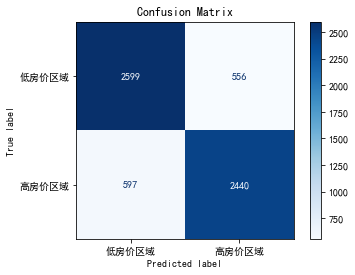

In [14]:
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = [ 'SimHei']
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['低房价区域', '高房价区域'])
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix")
plt.show()

显示可用的各种黑体字体

In [15]:
from matplotlib.font_manager import FontManager
fm = FontManager()
available_fonts = [f.name for f in fm.ttflist]
print("可用字体:", [f for f in available_fonts if 'Hei' in f or 'hei' in f])

可用字体: ['Microsoft YaHei', 'Microsoft YaHei', 'Microsoft MHei', 'Microsoft MHei', 'Microsoft JhengHei', 'Microsoft MHei', 'STXihei', 'SimHei', 'Microsoft JhengHei', 'Microsoft JhengHei', 'Microsoft JhengHei', 'STXihei', 'SimHei', 'Microsoft JhengHei', 'Microsoft JhengHei', 'Microsoft YaHei', 'Microsoft YaHei', 'Microsoft MHei', 'Microsoft YaHei', 'Microsoft YaHei']
